# MST-GNN Paper Replication — Kaggle Notebook

> **Paper**: "Graph Representation Learning of Multilayer Spatial-Temporal Networks for Stock Predictions" (IEEE TCSS, 2024)

## Setup checklist
Before running: **Settings → Accelerator → GPU T4 x2** (right panel)

## Pipeline
```
Phase 1: Data collection  (~1–5 min, cached after first run)
Phase 2: Preprocessing    (~15 sec)
Phase 3: Graph building   (~10–20 min, 1088 trading days × 4 networks)
Phase 4: Dataset creation (~2 min)
Phase 5: Training         (~30–45 min on T4 GPU, 200 epochs)
Phase 6: Backtest         (~1 min)
Total:                    ~50–75 min
```

## Step 1 — Verify GPU

In [1]:
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: GPU not available — go to Settings → Accelerator → GPU T4 x2")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


## Step 2 — Clone Repository

In [2]:
import os

REPO_URL  = "https://github.com/quocnguyen5/mst-gnn-impl.git"
WORK_DIR  = "/kaggle/working/mst-gnn-impl"

if os.path.exists(WORK_DIR):
    # Pull latest changes if repo already exists
    print("Repo exists — pulling latest changes...")
    os.system(f"git -C {WORK_DIR} pull")
else:
    print("Cloning repository...")
    os.system(f"git clone {REPO_URL} {WORK_DIR}")

os.chdir(WORK_DIR)
print(f"Working directory: {os.getcwd()}")
print("Files:", os.listdir("."))

Cloning repository...


Cloning into '/kaggle/working/mst-gnn-impl'...


Working directory: /kaggle/working/mst-gnn-impl
Files: ['train.py', 'README.md', 'utils', 'MST_GNN_Kaggle.ipynb', 'data', 'evaluate.py', 'experiments', '.DS_Store', 'config.py', 'MST_GNN_Colab.ipynb', 'backtest.py', '__pycache__', '.git', 'models', 'requirements.txt']


## Step 3 — Install Dependencies

In [3]:
import torch, subprocess, sys

# Core packages
!pip install -q akshare baostock gensim jieba tqdm

# Detect GPU compute capability and pick the right PyTorch + PyG version
pyt = torch.__version__.split('+')[0]
cuda_str = torch.version.cuda or 'cpu'
cuda_tag = cuda_str.replace('.', '')

if torch.cuda.is_available():
    cap = torch.cuda.get_device_capability(0)  # e.g. (6, 0) for P100
    cap_int = cap[0] * 10 + cap[1]              # e.g. 60 for sm_60
    print(f"GPU compute capability: sm_{cap_int}")

    if cap_int < 70:
        # P100 (sm_60) — needs PyTorch <= 2.1.x
        print("P100 detected (sm_60) — installing PyTorch 2.1.2 (last version supporting sm_60)")
        !pip install -q torch==2.1.2+cu121 torchvision==0.16.2+cu121 \
            --index-url https://download.pytorch.org/whl/cu121 \
            --force-reinstall -q
        pyg_torch = '2.1.2'
        pyg_cuda  = 'cu121'
    else:
        # T4/V100/A100 (sm_70+) — use current PyTorch
        print(f"GPU sm_{cap_int} — using installed PyTorch {pyt}")
        pyg_torch = pyt
        pyg_cuda  = f'cu{cuda_tag}'
else:
    print("No GPU — using CPU")
    pyg_torch = pyt
    pyg_cuda  = 'cpu'

print(f"Installing PyG for torch-{pyg_torch}+{pyg_cuda}...")
!pip install -q torch-scatter torch-sparse \
    -f https://data.pyg.org/whl/torch-{pyg_torch}+{pyg_cuda}.html
!pip install -q torch-geometric

import importlib
import torch_geometric
print(f"torch-geometric: {torch_geometric.__version__}")
print("\nNOTE: If PyTorch was downgraded, restart the kernel before proceeding!")
import torch
print(f"Active PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 113.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 103.1 MB/s eta 0:00:0000:01
GPU compute capability: sm_75
GPU sm_75 — using installed PyTorch 2.10.0
Installing PyG for torch-2.10.0+cu128...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 92.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 97.1 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.6 MB/s eta 0:00:0000:01
torch-geometric: 2.8.0

NOTE: If PyTorch was downgraded, restart the kernel before proceeding!
Active PyTorch: 2.10.0+cu128 | CUDA: True


## Step 4 — Sanity Check (Optional)
Run a quick 3-epoch test with synthetic data to verify the model works before the full run.

In [6]:
# Quick sanity check — synthetic data, 3 epochs, ~30 seconds on GPU
# Skip this cell if you want to go straight to the real experiment
import subprocess, sys
proc = subprocess.Popen(
    [sys.executable, "-m", "experiments.run_sanity_check"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1, cwd="/kaggle/working/mst-gnn-impl"
)
for line in iter(proc.stdout.readline, ""):
    print(line, end="", flush=True)
proc.wait()
print("Sanity check complete!" if proc.returncode == 0 else f"Exit code: {proc.returncode}")

INFO:sanity_check:Starting MST-GNN implementation sanity check...
INFO:sanity_check:Building synthetic datasets...
INFO:sanity_check:Initializing MST-GNN model...
INFO:sanity_check:Starting training loop...
INFO:train:Model parameters: 175,747
INFO:train:Module params: {'encoder': 24576, 'stna': 67072, 'hoff': 75584, 'predictor': 8515}
INFO:train:Device: cpu
2026-06-26 15:55:14.914103: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782489315.120921     155 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782489315.179360     155 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782489315.654354     155 computation_placer.cc:177] computation

## Step 5 — Run Main Experiment (CSI 300)

Full pipeline: data collection → preprocessing → graph building → training → backtest.

**Expected output during run:**
```
[Phase 1] Collecting data...        ~1-5 min
[Phase 2] Preprocessing...          ~15 sec
[Phase 3] Building graphs...        ~10-20 min  ← progress bar visible
[Phase 4] Creating dataset...       ~2 min
[Phase 5] Training MST-GNN...       ~30-45 min  ← epoch logs every 10 epochs
[Phase 6] Backtest...               ~1 min
```

In [7]:
# Run CSI 300 with mean aggregator — standard variant, fastest
# Output streams line-by-line for real-time progress monitoring
import subprocess, sys

proc = subprocess.Popen(
    [sys.executable, "-m", "experiments.run_main",
     "--dataset", "csi300",
     "--aggregator", "mean"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,   # merge stderr so all output is visible
    text=True, bufsize=1,
    cwd="/kaggle/working/mst-gnn-impl"
)

for line in iter(proc.stdout.readline, ""):
    print(line, end="", flush=True)

proc.wait()
print(f"\nProcess finished — return code: {proc.returncode}")


[Phase 1] Collecting data (loading from cache if available)...
  [Phase 1 done] 570.5s — 284,086 price rows, 5530 industry records

[Phase 2] Preprocessing — computing 13 features & sliding windows...
  [Phase 2 done] 6.9s — 1088 trading days, 282,365 samples
[Phase 3] Building graphs for 1088 trading days (this is the slowest step — ~5-15 min)
  Active stocks in universe: 287
  Building shareholding network (static)...
Empty shareholding data, returning empty network.
  Building industry network (static)...
  Training LDA topic model for topicality network...
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid 

In [ ]:
# Check if cache was found or baostock is fetching
import os

cache_file = "/kaggle/working/mst-gnn-impl/data/raw/daily_prices_2018-01-02_2022-06-30.parquet"
print("Cache exists:", os.path.exists(cache_file))

# Check if pyarrow is installed (needed to read .parquet)
try:
    import pyarrow
    print("pyarrow:", pyarrow.__version__)
except ImportError:
    print("pyarrow NOT installed! — installing now")
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyarrow"])
    print("pyarrow installed. Restart & run all needed.")



## Step 6 — Inspect Results
Verify snapshot count and display the backtest chart after training completes.

In [8]:
# Check cached snapshot count after training
import pickle, os

for dataset in ["csi300", "csi500"]:
    pkl = f"data/processed/{dataset}_snapshots.pkl"
    if os.path.exists(pkl):
        with open(pkl, "rb") as f:
            snaps = pickle.load(f)
        n = len(snaps)
        print(f"{dataset.upper():7s}: {n} snapshots "
              f"(train~{int(n*0.7)}, val~{int(n*0.1)}, test~{int(n*0.2)})")
    else:
        print(f"{dataset.upper():7s}: not built yet")

CSI300 : 1084 snapshots (train~758, val~108, test~216)
CSI500 : not built yet


--- CSI300 Cumulative Returns ---


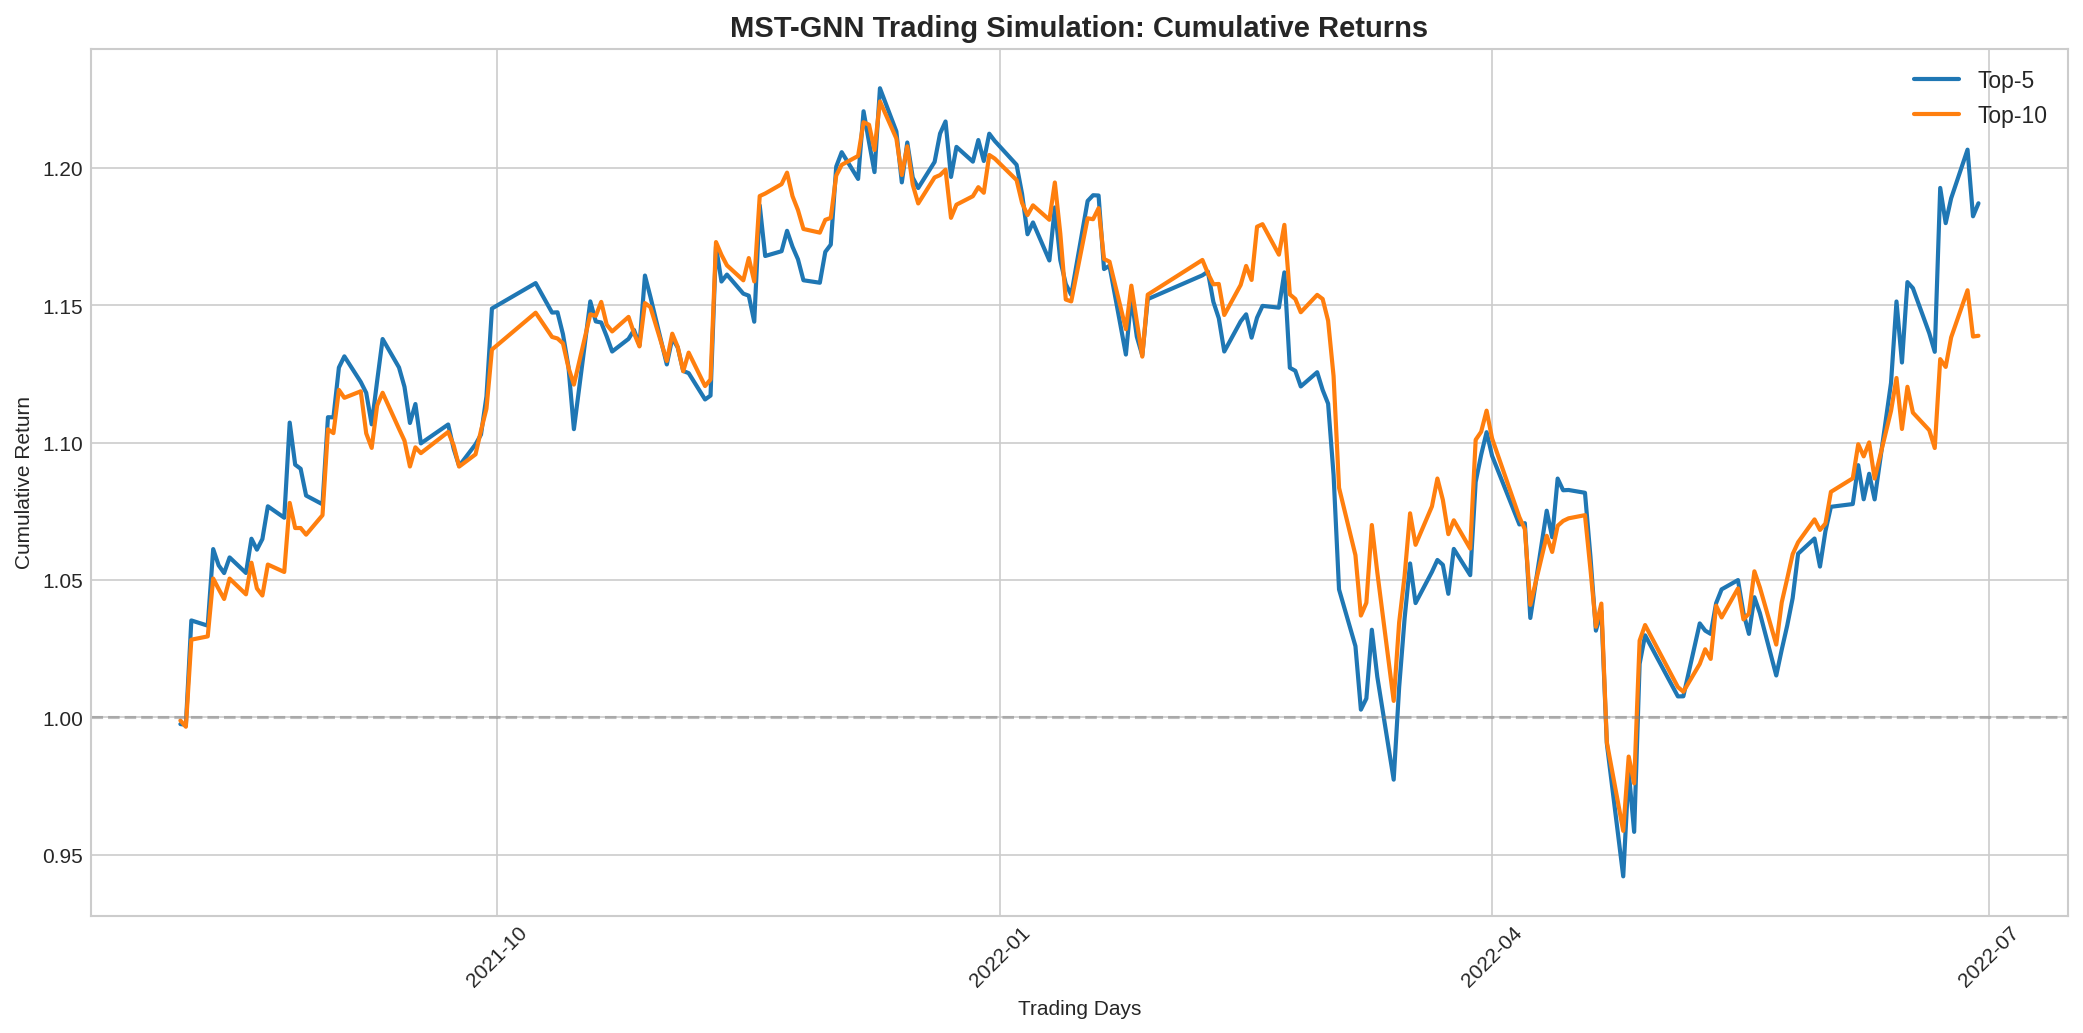

CSI500: no chart yet (run experiment first)


In [9]:
# Display saved backtest chart
from IPython.display import Image, display
import os

for dataset in ["csi300", "csi500"]:
    chart = f"checkpoints/cumulative_returns_{dataset}.png"
    if os.path.exists(chart):
        print(f"--- {dataset.upper()} Cumulative Returns ---")
        display(Image(filename=chart))
    else:
        print(f"{dataset.upper()}: no chart yet (run experiment first)")

## Step 7 — Ablation Study (Optional)
Compare all 3 STNA aggregator variants: mean, lstm, maxpool.
Reproduces Table VI from the paper.

> **Estimated time**: ~2–3 hours (3 full training runs)

In [ ]:
# Run all 3 aggregator variants and print a comparison table
import subprocess, sys

proc = subprocess.Popen(
    [sys.executable, "-m", "experiments.run_main",
     "--dataset", "csi300",
     "--aggregator", "all"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1, cwd="/kaggle/working/mst-gnn-impl"
)
for line in iter(proc.stdout.readline, ""):
    print(line, end="", flush=True)
proc.wait()


[Phase 1] Collecting data (loading from cache if available)...
  [Phase 1 done] 0.1s — 284,086 price rows, 5530 industry records

[Phase 2] Preprocessing — computing 13 features & sliding windows...
  [Phase 2 done] 6.5s — 1088 trading days, 282,365 samples
[Phase 3] Building graphs for 1088 trading days (this is the slowest step — ~5-15 min)
  Active stocks in universe: 287
  Building shareholding network (static)...
Empty shareholding data, returning empty network.
  Building industry network (static)...
  Training LDA topic model for topicality network...
Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Loading model from cache /tmp/jieba.cache
DEBUG:jieba:Loading model from cache /tmp/jieba.cache
Loading model cost 0.772 seconds.
DEBUG:jieba:Loading model cost 0.772 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.

  [Graph build]: 100%|█████████████████████| 

## Step 8 — Vietnam Market Extension (VN30 / VN100)

Apply MST-GNN to Vietnamese stocks (HOSE exchange) using the `vnstock` library.

**Active networks:**
| Network | Status |
|---|---|
| Comovement | ✅ Active (price correlation) |
| Industry | ✅ Active (ICB classification via vnstock) |
| Shareholding | ⚪ Empty (future work) |
| Topicality | ⚪ Empty (requires Vietnamese NLP — future work) |

In [ ]:
# Install vnstock — free Vietnam stock data (works globally, no API key)
!pip install -q vnstock
print("vnstock installed.")

In [ ]:
# Run MST-GNN on VN30 — fastest Vietnam experiment (~30-45 min)
import subprocess, sys

proc = subprocess.Popen(
    [sys.executable, "-m", "experiments.run_vn",
     "--universe", "vn30",
     "--aggregator", "mean"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1, cwd="/kaggle/working/mst-gnn-impl"
)
for line in iter(proc.stdout.readline, ""):
    print(line, end="", flush=True)
proc.wait()
print(f"\nVN30 experiment done — return code: {proc.returncode}")

In [ ]:
# Run MST-GNN on VN Top 100 — recommended for lab presentation (~60-90 min)
import subprocess, sys

proc = subprocess.Popen(
    [sys.executable, "-m", "experiments.run_vn",
     "--universe", "vn100",
     "--aggregator", "mean"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1, cwd="/kaggle/working/mst-gnn-impl"
)
for line in iter(proc.stdout.readline, ""):
    print(line, end="", flush=True)
proc.wait()
print(f"\nVN100 experiment done — return code: {proc.returncode}")

In [ ]:
# Inspect VN results
import pickle, os
from IPython.display import Image, display

print("=== Vietnam Dataset Status ===")
for universe in ["vn30", "vn100"]:
    pkl = f"data/processed_vn/{universe}_snapshots.pkl"
    if os.path.exists(pkl):
        with open(pkl, "rb") as f:
            snaps = pickle.load(f)
        n = len(snaps)
        print(f"{universe.upper():6s}: {n} snapshots "
              f"(train~{int(n*0.7)}, val~{int(n*0.1)}, test~{int(n*0.2)})")
    else:
        print(f"{universe.upper():6s}: not built yet")

# Display charts
for universe in ["vn30", "vn100"]:
    chart = f"checkpoints/cumulative_returns_{universe}.png"
    if os.path.exists(chart):
        print(f"\n--- {universe.upper()} Cumulative Returns ---")
        display(Image(filename=chart))